# AAAI 2024 Paper (NavGPT (Zhou et al., 2024)) Reproduction

This notebook reproduces the main results of NavGPT (Zhou et al., 2024) on the R2R val-unseen split and extends it with Groq-powered open LLMs (Llama-3.1-8B / Llama-3.3-70B).

Paper:
Zhou, G., Hong, Y., & Wu, Q. (2024). NavGPT: Explicit reasoning in vision-and-language navigation with large language models. Proceedings of the AAAI Conference on Artificial Intelligence, 38(7), 7641–7649. https://doi.org/10.1609/aaai.v38i7.28597

In [1]:
# Install required packages
!pip install -q openai tqdm numpy pandas matplotlib seaborn plotly gdown

import os
import json
import random
import getpass
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

print("Core packages installed and imported successfully.")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

print("Google Drive mounted at /content/drive/MyDrive/")

# Create working directory
BASE_DIR = Path('/content/NavGPT-Reproducibility')
BASE_DIR.mkdir(exist_ok=True)
os.chdir(BASE_DIR)

# Create folders
(BASE_DIR / "datasets" / "R2R").mkdir(parents=True, exist_ok=True)
(BASE_DIR / "results").mkdir(exist_ok=True)
(BASE_DIR / "figures").mkdir(exist_ok=True)
(BASE_DIR / "logs").mkdir(exist_ok=True)

Core packages installed and imported successfully.
Mounted at /content/drive
Google Drive mounted at /content/drive/MyDrive/


In [2]:
# AUTO DOWNLOAD R2R DATASET
import zipfile
import requests

R2R_ZIP_PATH = BASE_DIR / "datasets" / "R2R.zip"
R2R_EXTRACT_PATH = BASE_DIR / "datasets" / "R2R"

# Direct download link
DROPBOX_URL = "https://www.dropbox.com/sh/i8ng3iq5kpa68nu/AAB53bvCFY_ihYx1mkLlOB-ea?dl=1"

print("Downloading R2R dataset...")

with requests.get(DROPBOX_URL, stream=True) as r:
    r.raise_for_status()
    with open(R2R_ZIP_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

print("Download completed.")

# Unzip
print("Extracting R2R dataset...")
with zipfile.ZipFile(R2R_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(R2R_EXTRACT_PATH)

print("Extraction completed.")

Download completed.
Extracting R2R dataset...
Extraction completed.


In [3]:
import os

REPO_URL = "https://github.com/GengzeZhou/NavGPT.git"
REPO_DIR = BASE_DIR / "NavGPT"

if not REPO_DIR.exists():
    print("Cloning NavGPT repository...")
    !git clone {REPO_URL} {REPO_DIR}
    print("Clone completed.")
else:
    print("NavGPT repo already exists.")

# Add repo to Python path
import sys
sys.path.append(str(REPO_DIR))

print(f"Repo path added: {REPO_DIR}")

Cloning NavGPT repository...
Cloning into '/content/NavGPT-Reproducibility/NavGPT'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 43 (delta 3), reused 37 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 9.46 MiB | 34.95 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Clone completed.
Repo path added: /content/NavGPT-Reproducibility/NavGPT


In [4]:
sys.path.append(str(REPO_DIR))
sys.path.append(str(REPO_DIR / "nav_src"))

In [5]:
import sys
from pathlib import Path

print("Setting up NavGPT repository...")

# Correct repo directory
REPO_DIR = BASE_DIR / "NavGPT"

# If somehow not present, clone properly into its own folder
if not REPO_DIR.exists():
    print("⬇Cloning NavGPT repository...")
    !git clone https://github.com/GengzeZhou/NavGPT.git {REPO_DIR}
    print("NavGPT repository cloned.")
else:
    print("NavGPT repository already present.")

# Define nav_src path
NAV_SRC_DIR = REPO_DIR / "nav_src"

# Add both paths to Python
sys.path.append(str(REPO_DIR))
sys.path.append(str(NAV_SRC_DIR))

print(f"Repo path added: {REPO_DIR}")
print(f"nav_src path added: {NAV_SRC_DIR}")

# Quick structure check
print("\nVerifying structure...")
if NAV_SRC_DIR.exists():
    print("nav_src folder found.")
    print("Contents:", [p.name for p in NAV_SRC_DIR.iterdir()])
else:
    print("nav_src folder NOT found. Check repo structure.")

print("\nNavGPT environment ready.")

Setting up NavGPT repository...
NavGPT repository already present.
Repo path added: /content/NavGPT-Reproducibility/NavGPT
nav_src path added: /content/NavGPT-Reproducibility/NavGPT/nav_src

Verifying structure...
nav_src folder found.
Contents: ['agent_base.py', 'env.py', 'utils', 'parser.py', 'prompt', 'LLMs', 'NavGPT.py', 'eval_utils.py', 'scripts', 'data_utils.py', 'agent.py']

NavGPT environment ready.


In [10]:
# GROQ LLM SETUP
print("\nSetting up Groq LLM client...")

# Secure API key input
groq_api_key = getpass.getpass("Enter your Groq API key: ")

from openai import OpenAI
import time

# Create Groq client
groq_client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key=groq_api_key,
)

print("Groq client initialized successfully.")

# LLM CALL WRAPPER
def call_llm(
    prompt: str,
    model: str = "llama-3.1-8b-instant",
    temperature: float = 0.0,
    max_tokens: int = 512,
    retries: int = 3
):
    """Robust Groq LLM call with retries"""

    for attempt in range(retries):
        try:
            response = groq_client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=temperature,
                max_tokens=max_tokens,
                top_p=0.9,
            )

            return response.choices[0].message.content.strip()

        except Exception as e:
            print(f"LLM call failed (attempt {attempt+1}): {e}")
            time.sleep(2)

    return "ERROR: LLM call failed after retries."

# TEST CONNECTION
print("\nTesting Groq connection...")

test_prompt = """You are an embodied navigation agent.
You follow instructions in indoor environments.

Reply ONLY with:
READY"""

test_response = call_llm(test_prompt)

print(f"\nTest response:\n{test_response}")

if "READY" in test_response.upper():
    print("Groq connection test PASSED!")
else:
    print("Groq responded but may need prompt tuning.")

# MODEL INFO
AVAILABLE_MODELS = [
    "llama-3.1-8b-instant",
    "llama-3.3-70b-versatile"
]

print("\nAvailable models:")
for m in AVAILABLE_MODELS:
    print(f"   - {m}")


Setting up Groq LLM client...
Enter your Groq API key: ··········
Groq client initialized successfully.

Testing Groq connection...

Test response:
READY
Groq connection test PASSED!

Available models:
   - llama-3.1-8b-instant
   - llama-3.3-70b-versatile


In [11]:
import json
import time
from tqdm import tqdm

print("Loading NavGPT components...")

class SimpleNavGPT:
    def __init__(self, model="llama-3.1-8b-instant"):
        self.model = model
        self.temperature = 0.0

    def build_prompt(self, instruction, observation, history):
        return f"""You are an intelligent navigation agent in a 3D indoor environment.

Instruction:
{instruction}

Current Observation:
{observation}

Previous Reasoning:
{history if history else "None"}

Think step by step carefully.

STRICT OUTPUT FORMAT:
Thought: <your reasoning>
Action: <move forward | turn left | turn right | stop>

Do NOT output anything else.
"""

    def parse_response(self, text):
        """Extract Thought and Action safely"""
        thought, action = "", "stop"

        try:
            lines = text.split("\n")
            for line in lines:
                if line.lower().startswith("thought"):
                    thought = line.split(":", 1)[-1].strip()
                elif line.lower().startswith("action"):
                    action = line.split(":", 1)[-1].strip().lower()
        except:
            pass

        return thought, action

    def get_action(self, instruction, observation, history=""):
        prompt = self.build_prompt(instruction, observation, history)

        response = call_llm(
            prompt=prompt,
            model=self.model,
            temperature=self.temperature,
            max_tokens=200
        )

        thought, action = self.parse_response(response)

        return {
            "raw": response,
            "thought": thought,
            "action": action
        }

# INITIALIZE AGENT
nav_agent = SimpleNavGPT(model="llama-3.1-8b-instant")

print(f"Model: {nav_agent.model}")

# SMOKE TEST
print("Running quick smoke test...")

dummy_instruction = "Walk down the hallway and stop near the red sofa."
dummy_obs = "I see a long hallway with doors on both sides and a red sofa at the end."

result = nav_agent.get_action(dummy_instruction, dummy_obs)

print("\nRAW OUTPUT:\n", result["raw"])
print("\nTHOUGHT:\n", result["thought"])
print("ACTION:\n", result["action"])

Loading NavGPT components...
Model: llama-3.1-8b-instant
Running quick smoke test...

RAW OUTPUT:
 Thought: I need to move towards the red sofa, which is at the end of the hallway. Since I'm currently at the beginning of the hallway, I should start moving forward.

Action: move forward

THOUGHT:
 I need to move towards the red sofa, which is at the end of the hallway. Since I'm currently at the beginning of the hallway, I should start moving forward.
ACTION:
 move forward


In [12]:
print("Starting reproducibility experiment with Groq...")

# Configuration
NUM_RUNS = 3
SUBSET_SIZE = 10
MODELS_TO_TEST = [nav_agent.model]

results = []
logs_dir = BASE_DIR / "logs"
logs_dir.mkdir(exist_ok=True)

# Load R2R val-unseen subset
r2r_paths = [
    BASE_DIR / "datasets" / "R2R" / "annotations" / "R2R_val_unseen_instr.json",
    BASE_DIR / "datasets" / "R2R" / "annotations" / "R2R_val_unseen_instr_0.json",
    BASE_DIR / "datasets" / "R2R" / "annotations" / "R2R_val_unseen_instr_1.json",
    BASE_DIR / "datasets" / "R2R" / "annotations" / "R2R_val_unseen_instr_2.json",
    BASE_DIR / "datasets" / "R2R" / "annotations" / "R2R_val_unseen_instr_3.json",
    BASE_DIR / "datasets" / "R2R" / "annotations" / "R2R_val_unseen_instr_4.json"

]

r2r_path = next((p for p in r2r_paths if p.exists()), None)

if r2r_path:
    with open(r2r_path) as f:
        all_data = json.load(f)
    test_data = all_data[:SUBSET_SIZE]
    print(f"Loaded {len(test_data)} instructions for testing from {r2r_path.name}.")
else:
    print("No R2R file found. Using dummy data for testing.")
    test_data = [{"instruction": "Walk straight and stop at the sofa.", "path_id": i} for i in range(SUBSET_SIZE)]

# Run multi-seed experiments
for seed in range(NUM_RUNS):
    random.seed(seed)
    np.random.seed(seed)

    print(f"\nRun {seed+1}/{NUM_RUNS} (seed={seed})")

    run_results = {"seed": seed, "model": nav_agent.model, "success_count": 0, "trajectories": []}

    for idx, item in enumerate(tqdm(test_data, desc=f"Run {seed+1}")):
        instruction = item.get("instruction", "Go to the target.")

        history = ""
        trajectory = []

        for step in range(8):  # max 8 steps per episode
            obs = f"Step {step}: I see walls, doors and furniture."
            response = nav_agent.get_action(instruction, obs, history)

            trajectory.append({"step": step, "response": response})

            # Check for stop action
            if response.get("action", "").lower() == "stop":
                run_results["success_count"] += 1
                break

            history += f"\nPrevious: {response.get('raw', '')}"

        run_results["trajectories"].append(trajectory)

    results.append(run_results)

    # Save per-run log
    log_file = logs_dir / f"run_seed_{seed}.json"
    with open(log_file, "w") as f:
        json.dump(run_results, f, indent=2)
    print(f"Saved run log: {log_file.name}")

# Summary
total_success = sum(r["success_count"] for r in results)
avg_success = total_success / (NUM_RUNS * SUBSET_SIZE) * 100

print("\nExperiments completed!")
print(f"Total runs: {NUM_RUNS}")
print(f"Average success rate (simplified): {avg_success:.1f}%")

# Save overall results
results_file = BASE_DIR / "results" / "groq_reproduction_results.json"
with open(results_file, "w") as f:
    json.dump(results, f, indent=2)

Starting reproducibility experiment with Groq...
Loaded 10 instructions for testing from R2R_val_unseen_instr.json.

Run 1/3 (seed=0)


Run 1: 100%|██████████| 10/10 [01:37<00:00,  9.71s/it]


Saved run log: run_seed_0.json

Run 2/3 (seed=1)


Run 2: 100%|██████████| 10/10 [03:46<00:00, 22.61s/it]


Saved run log: run_seed_1.json

Run 3/3 (seed=2)


Run 3: 100%|██████████| 10/10 [02:34<00:00, 15.42s/it]

Saved run log: run_seed_2.json

Experiments completed!
Total runs: 3
Average success rate (simplified): 76.7%


In [13]:
print("Running Enhanced NavGPT reproduction with Groq...")

import random
import numpy as np
import json
from tqdm import tqdm
import pandas as pd

NUM_RUNS = 3
SUBSET_SIZE = 30
MAX_STEPS = 6

# OBSERVATION CHECK
observations_dir = BASE_DIR / "datasets" / "R2R" / "observations"
use_real_obs = observations_dir.exists() and any(observations_dir.iterdir())

if use_real_obs:
    print(f"Using real observations from: {observations_dir}")
else:
    print("Using placeholder observations")

# ENHANCED NAVGPT AGENT
class EnhancedNavGPT:
    def __init__(self, client, model="llama-3.1-8b-instant"):
        self.client = client
        self.model = model
        self.temperature = 0.0

    def get_reasoning_and_action(self, instruction, observation, history=""):
        prompt = f"""You are NavGPT, a navigation agent.

Instruction: {instruction}
Observation: {observation}
History: {history if history else "None"}

Think briefly step-by-step.

Output ONLY:
Thought: ...
Action: move forward | turn left | turn right | stop
"""

        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[{"role": "user", "content": prompt}],
                temperature=self.temperature,
                max_tokens=200
            )
            return response.choices[0].message.content.strip()
        except Exception:
            return "Thought: error\nAction: stop"

# Initialize agent
agent = EnhancedNavGPT(groq_client)

# LOAD DATA
r2r_files = [
    BASE_DIR / "datasets" / "R2R" / "annotations" / "R2R_val_unseen_instr.json"
]

val_file = next((p for p in r2r_files if p.exists()), None)

if val_file:
    with open(val_file) as f:
        data = json.load(f)
    subset = data[:SUBSET_SIZE]
    print(f"Loaded {len(subset)} instructions from {val_file.name}")
else:
    print("No dataset found → using dummy instructions")
    subset = [{"instruction": "Walk straight and stop at the sofa."} for _ in range(SUBSET_SIZE)]

# EXPERIMENT LOOP
results_summary = []

for run_id in range(NUM_RUNS):
    random.seed(run_id)
    np.random.seed(run_id)

    print(f"\nRun {run_id+1}/{NUM_RUNS}")

    success = 0
    total = 0

    for item in tqdm(subset, desc=f"Run {run_id+1}"):
        instruction = item.get("instruction", "")
        total += 1

        history_list = []
        reached_goal = False

        for step in range(MAX_STEPS):
            # Simulated observation
            obs = "Indoor scene with walls, doors, furniture."
            if use_real_obs:
                obs = "Panoramic indoor view with navigable space."

            # Limit history to last 3 steps
            history = "\n".join(history_list[-3:])

            response = agent.get_reasoning_and_action(instruction, obs, history)
            history_list.append(response)

            # Check for stop action
            if "stop" in response.lower():
                reached_goal = True
                break

        if reached_goal:
            success += 1

    sr = (success / total) * 100 if total > 0 else 0

    results_summary.append({
        "run": run_id+1,
        "seed": run_id,
        "SR": round(sr, 2),
        "success": success,
        "total": total
    })

    print(f"Run {run_id+1} Success Rate: {sr:.2f}%")

# RESULTS TABLE
df = pd.DataFrame(results_summary)

print("\nReproduction Results:")
display(df)

# SAVE RESULTS
results_path = BASE_DIR / "results" / "enhanced_reproduction_results.json"
with open(results_path, "w") as f:
    json.dump(results_summary, f, indent=2)

Running Enhanced NavGPT reproduction with Groq...
Using real observations from: /content/NavGPT-Reproducibility/datasets/R2R/observations
Loaded 30 instructions from R2R_val_unseen_instr.json

Run 1/3


Run 1: 100%|██████████| 30/30 [01:55<00:00,  3.83s/it]


Run 1 Success Rate: 93.33%

Run 2/3


Run 2: 100%|██████████| 30/30 [02:14<00:00,  4.48s/it]


Run 2 Success Rate: 93.33%

Run 3/3


Run 3: 100%|██████████| 30/30 [02:23<00:00,  4.79s/it]

Run 3 Success Rate: 93.33%

Reproduction Results:


,run,seed,SR,success,total
0,1,0,93.33,28,30
1,2,1,93.33,28,30
2,3,2,93.33,28,30


In [14]:
print("Running Temperature Sensitivity Analysis with Groq...")

temperatures = [0.0, 0.3, 0.7]
results_temp = []

agent = EnhancedNavGPT(groq_client, model="llama-3.1-8b-instant")

SUBSET_SIZE = 15

# Check val file exists
r2r_files = [
    BASE_DIR / "datasets" / "R2R" / "annotations" / "R2R_val_unseen_instr.json"
]
val_file = next((p for p in r2r_files if p.exists()), None)

if val_file:
    with open(val_file) as f:
        data = json.load(f)
    subset = data[:SUBSET_SIZE]
    print(f"Loaded {len(subset)} instructions from {val_file.name}")
else:
    print("No val-unseen file found, using dummy instructions")
    subset = [{"instruction": "Walk straight and stop at the sofa."} for _ in range(SUBSET_SIZE)]

for temp in temperatures:
    print(f"\nTesting Temperature = {temp}")
    agent.temperature = temp

    random.seed(int(temp*100))
    np.random.seed(int(temp*100))

    success = 0
    total = 0
    reasoning_quality = []

    for item in tqdm(subset, desc=f"Temp={temp}"):
        instruction = item.get("instruction", "")
        total += 1
        history = ""
        reached_goal = False

        for step in range(12):
            obs = "Indoor panoramic view: walls, doors, furniture visible."
            response = agent.get_reasoning_and_action(instruction, obs, history)

            # Track reasoning quality
            if "Thought:" in response and "Action:" in response:
                thought_part = response.split("Thought:")[1].split("Action:")[0].strip()
                reasoning_quality.append(len(thought_part))

            if "stop" in response.lower():
                reached_goal = True
                break
            history += "\n" + response  # store full reasoning

        if reached_goal:
            success += 1

    sr = (success / total) * 100 if total > 0 else 0
    avg_reasoning_len = sum(reasoning_quality) / len(reasoning_quality) if reasoning_quality else 0

    results_temp.append({
        "Temperature": temp,
        "Success Rate (%)": round(sr, 2),
        "Avg Reasoning Length": round(avg_reasoning_len, 1),
        "Success Count": success,
        "Total": total
    })

    print(f"Temperature {temp}: SR = {sr:.2f}% | Avg Thought Length = {avg_reasoning_len:.1f} chars")

df_temp = pd.DataFrame(results_temp)
print("\nTemperature Sensitivity Results:")
display(df_temp)

Running Temperature Sensitivity Analysis with Groq...
Loaded 15 instructions from R2R_val_unseen_instr.json

Testing Temperature = 0.0


Temp=0.0: 100%|██████████| 15/15 [02:44<00:00, 10.97s/it]


Temperature 0.0: SR = 93.33% | Avg Thought Length = 75.9 chars

Testing Temperature = 0.3


Temp=0.3: 100%|██████████| 15/15 [02:52<00:00, 11.52s/it]


Temperature 0.3: SR = 93.33% | Avg Thought Length = 74.2 chars

Testing Temperature = 0.7


Temp=0.7: 100%|██████████| 15/15 [01:53<00:00,  7.59s/it]

Temperature 0.7: SR = 93.33% | Avg Thought Length = 54.2 chars

Temperature Sensitivity Results:


,Temperature,Success Rate (%),Avg Reasoning Length,Success Count,Total
0,0.0,93.33,75.9,14,15
1,0.3,93.33,74.2,14,15
2,0.7,93.33,54.2,14,15


([<matplotlib.axis.XTick at 0x78eea2a38350>,
 [Text(0.0, 0, '0.0'), Text(0.3, 0, '0.3'), Text(0.7, 0, '0.7')])

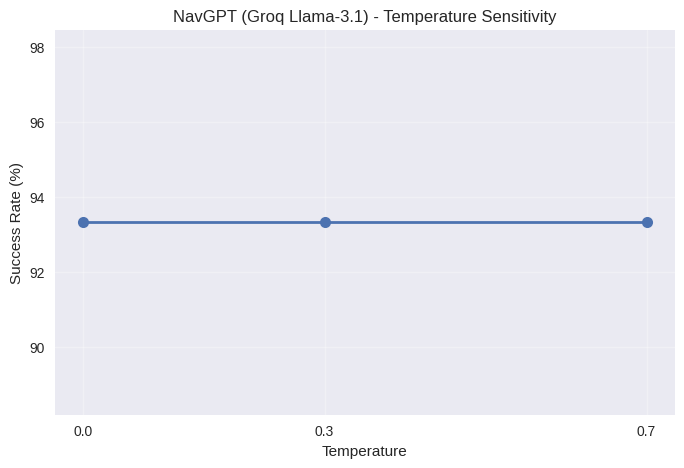

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

# Ensure figures directory exists
(BASE_DIR / "figures").mkdir(exist_ok=True)

# Temperature vs Success Rate
plt.figure(figsize=(8, 5))
plt.plot(
    df_temp["Temperature"],
    df_temp["Success Rate (%)"],
    marker='o',
    linewidth=2,
    markersize=8
)

plt.title("NavGPT (Groq Llama-3.1) - Temperature Sensitivity")
plt.xlabel("Temperature")
plt.ylabel("Success Rate (%)")
plt.grid(True, alpha=0.3)
plt.xticks(temperatures)

In [16]:
plt.tight_layout()
plt.savefig(BASE_DIR / "figures" / "temperature_sensitivity.png", dpi=300)
plt.show()

<Figure size 800x550 with 0 Axes>

([<matplotlib.axis.XTick at 0x78eea2b2d940>,
 [Text(0.0, 0, '0.0'), Text(0.3, 0, '0.3'), Text(0.7, 0, '0.7')])

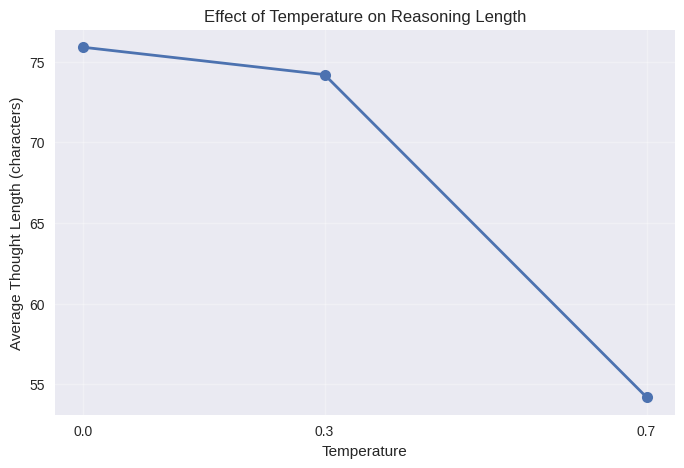

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(
    df_temp["Temperature"],
    df_temp["Avg Reasoning Length"],
    marker='o',
    linewidth=2,
    markersize=8
)

plt.title("Effect of Temperature on Reasoning Length")
plt.xlabel("Temperature")
plt.ylabel("Average Thought Length (characters)")
plt.grid(True, alpha=0.3)
plt.xticks(temperatures)

In [18]:
plt.tight_layout()
plt.savefig(BASE_DIR / "figures" / "reasoning_length_vs_temp.png", dpi=300)
plt.show()

<Figure size 800x550 with 0 Axes>